# Employee Attrition Analysis
## Part 2: Predictive Modelling
**Author:** Fariz Yusri  
**Date:** May 2026

## Data Preparation from EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE


df = pd.read_excel(r'C:\Users\fariz\OneDrive - National University of Singapore\Desktop\NHG_GHR Task_April_2026.xlsx')
df['AttritionBinary'] = (df['Attrition'] == 'Yes').astype(int)

print(f'Data: {df.shape[0]:,} No. of employes with {df.shape[1]} features')
print(f'Attrition breakdown:\n{df["Attrition"].value_counts()}\n')

Data: 1,470 No. of employes with 32 features
Attrition breakdown:
Attrition
No     1233
Yes     237
Name: count, dtype: int64



---
## 1. Feature Engineering & Preprocessing

### 1a. Feature Justification

Based on the EDA, we select features that showed meaningful association with attrition. We drop:
- `EmployeeNumber` — identifier only, no predictive value
- `StandardHours` — zero variance (all employees have the same value)
- `Attrition` / `AttritionBin` — these are our target variable

In [ ]:
# 
cat_cols = ['Department', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

df_model = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_model[col + '_enc'] = le.fit_transform(df_model[col]) #create new encoded column

# Drop original categorical columns and other columnns that will not be used in modelling
drop_cols = ['EmployeeNumber', 'StandardHours', 'Attrition', 'AttritionBinary'] + cat_cols
X = df_model.drop(columns=drop_cols)
y = df_model['AttritionBinary']

print('Features used in modelling:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')
print(f'Total features: {X.shape[1]}')

Features used in modelling:
   1. Age
   2. DailyRate
   3. DistanceFromHome
   4. Education
   5. EnvironmentSatisfaction
   6. HourlyRate
   7. JobInvolvement
   8. JobLevel
   9. JobSatisfaction
  10. MonthlyIncome
  11. MonthlyRate
  12. NumCompaniesWorked
  13. PercentSalaryHike
  14. PerformanceRating
  15. RelationshipSatisfaction
  16. StockOptionLevel
  17. TotalWorkingYears
  18. TrainingTimesLastYear
  19. WorkLifeBalance
  20. YearsAtCompany
  21. YearsInCurrentRole
  22. YearsSinceLastPromotion
  23. YearsWithCurrManager
  24. Department_enc
  25. Gender_enc
  26. JobRole_enc
  27. MaritalStatus_enc
  28. OverTime_enc
Total features: 28


In [ ]:
# Creae stratified train-test split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')
print(f'\nTrain attrition rate: {y_train.mean()*100:.1f}%')
print(f'Test  attrition rate: {y_test.mean()*100:.1f}%')

Training set : 1,176 rows
Test set     : 294 rows

Train attrition rate: 16.2%
Test  attrition rate: 16.0%


In [ ]:
# Class imabalance can be handled with SMOTE 

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('After SMOTE resampling:')
print(pd.Series(y_train_bal).value_counts())

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

After SMOTE resampling:
AttritionBinary
0    986
1    986
Name: count, dtype: int64


---
## 2. Model Training

We compare **three models**:

| Model | Rationale |
|---|---|
| **Logistic Regression** | Interpretable baseline and coefficients give direct insight into feature direction |
| **Random Forest** | Handles non-linear interactions, robust to outliers and built-in feature importance |
| **Gradient Boosting** | Often highest accuracy; captures complex patterns |

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=0.5),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42),
}

trained = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train_bal)
    else:
        model.fit(X_train_bal, y_train_bal)
    trained[name] = model
    print(f'{name} trained')

Logistic Regression trained
Random Forest trained
Gradient Boosting trained


---
## 3. Evaluation Metrics and Justification

For an **imbalanced binary classification** problem like attrition prediction, accuracy alone is misleading. We can then use:

| Metric | Why it matters here |
|---|---|
| **ROC-AUC** | Measures discriminative ability across all thresholds |
| **Precision-Recall AUC** | Better than ROC-AUC when classes are imbalanced as it focuses on the minority class (Yes) |
| **F1 Score (minority class)** | Harmonic mean of precision and recall for the "Yes" class |
| **Recall (Sensitivity)** | Highlights at-risk employees as missing them is costly |
| **Confusion Matrix** | Determines false negatives (or missed at-risk staff) |

In [ ]:
results = {}

for name, model in trained.items():
    X_eval = X_test_scaled if name == 'Logistic Regression' else X_test
    y_pred      = model.predict(X_eval)
    y_prob      = model.predict_proba(X_eval)[:, 1]

    roc_auc  = roc_auc_score(y_test, y_prob)
    pr_auc   = average_precision_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred, pos_label=1)
    recall   = (confusion_matrix(y_test, y_pred)[1, 1] /
                confusion_matrix(y_test, y_pred)[1].sum())

    results[name] = {
        'ROC-AUC': roc_auc, 'PR-AUC': pr_auc,
        'F1 (Attrition)': f1 , 'Recall (Attrition)': recall,
        'y_pred': y_pred, 'y_prob': y_prob
    }

# Summary table, remove y_pred and y_prob for cleaner display
summary = pd.DataFrame({
    name: {k: v for k, v in r.items() if k not in ['y_pred', 'y_prob']}
    for name, r in results.items()
}).T.round(4)

print('Model Performance Summary')
print('=' * 67)
print(summary.to_string())

Model Performance Summary
                     ROC-AUC  PR-AUC  F1 (Attrition)  Recall (Attrition)
Logistic Regression   0.7368  0.4587          0.4286              0.5106
Random Forest         0.7344  0.3454          0.4231              0.4681
Gradient Boosting     0.7545  0.4228          0.4490              0.4681


---
## 4. ROC Curves & Precision-Recall Curves

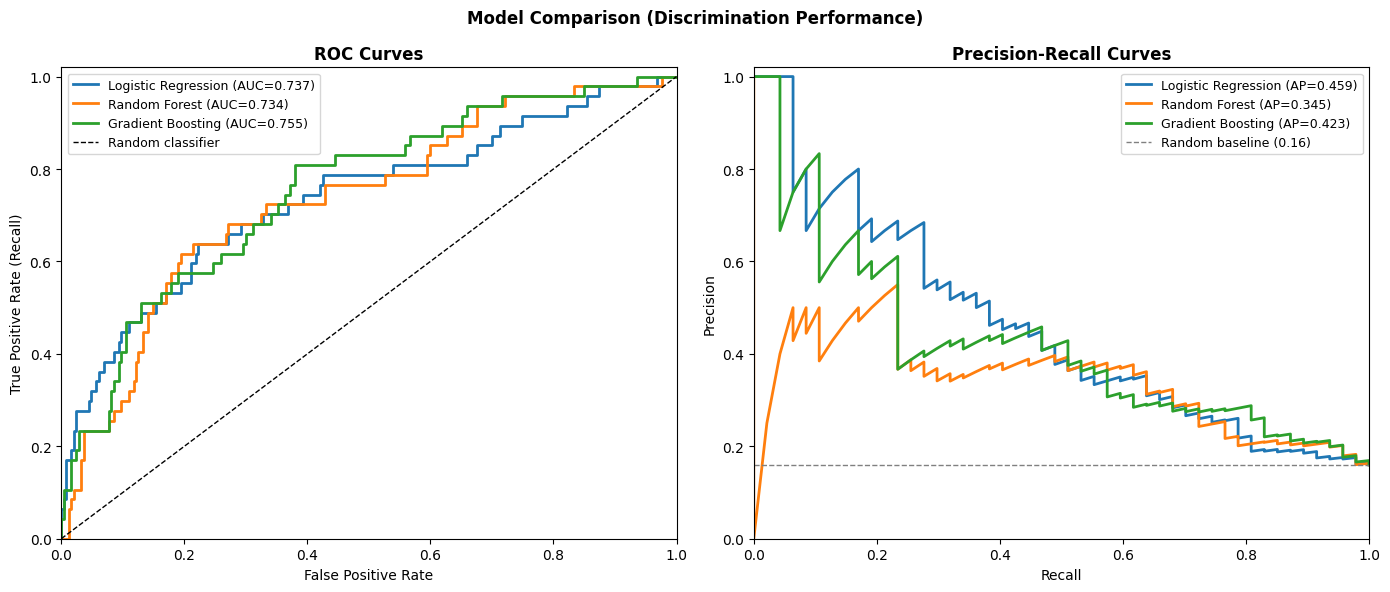

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, r in results.items():
    # ROC
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[0].plot(fpr, tpr, linewidth=2,
                 label=f"{name} (AUC={r['ROC-AUC']:.3f})")

    # PR
    prec, rec, _ = precision_recall_curve(y_test, r['y_prob'])
    axes[1].plot(rec, prec, linewidth=2,
                 label=f"{name} (AP={r['PR-AUC']:.3f})")

# ROC chart formatting
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(fontsize=9)
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])

# PR chart formatting
baseline = y_test.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', linewidth=1,
                label=f'Random baseline ({baseline:.2f})')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])

plt.suptitle('Model Comparison (Discrimination Performance)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Confusion Matrices

Logistic Regression - False Negatives (missed at-risk employees): 23
Random Forest - False Negatives (missed at-risk employees): 25
Gradient Boosting - False Negatives (missed at-risk employees): 25


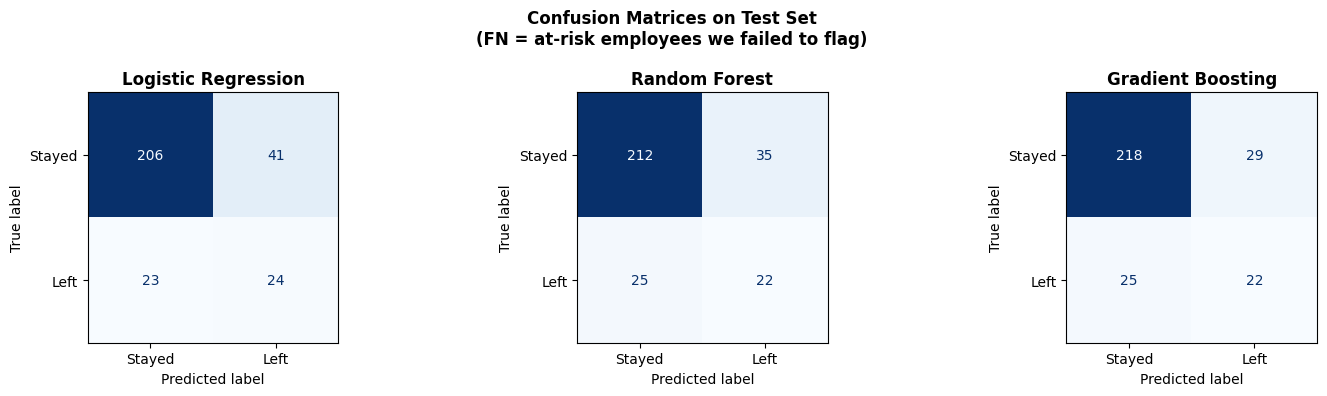

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Stayed', 'Left'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

    # FN (missed at-risk employees)
    fn = cm[1, 0]
    print(f'{name} - False Negatives (missed at-risk employees): {fn}')

plt.suptitle('Confusion Matrices on Test Set\n(FN = at-risk employees we failed to flag)',
             fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Full Classification Reports

In [ ]:
for name, r in results.items():
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(classification_report(y_test, r['y_pred'],
                                 target_names=['Stayed (0)', 'Left (1)']))


  Logistic Regression
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.83      0.87       247
    Left (1)       0.37      0.51      0.43        47

    accuracy                           0.78       294
   macro avg       0.63      0.67      0.65       294
weighted avg       0.81      0.78      0.80       294


  Random Forest
              precision    recall  f1-score   support

  Stayed (0)       0.89      0.86      0.88       247
    Left (1)       0.39      0.47      0.42        47

    accuracy                           0.80       294
   macro avg       0.64      0.66      0.65       294
weighted avg       0.81      0.80      0.80       294


  Gradient Boosting
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.88      0.89       247
    Left (1)       0.43      0.47      0.45        47

    accuracy                           0.82       294
   macro avg       0.66      0.68      0.67       294
weighted avg 

---
## 7. Cross-Validation (5-Fold Stratified)

In [ ]:

from imblearn.pipeline import Pipeline as ImbPipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_pipelines = {
    'Logistic Regression': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42, C=0.5))
    ]),
    'Random Forest': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(n_estimators=300, max_depth=8,
                                          min_samples_leaf=5, random_state=42,
                                          class_weight='balanced'))
    ]),
    'Gradient Boosting': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                              max_depth=4, subsample=0.8, random_state=42))
    ]),
}

cv_results = {}
for name, pipeline in cv_pipelines.items():
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<25} ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression       ROC-AUC: 0.7536 ± 0.0256
Random Forest             ROC-AUC: 0.7533 ± 0.0151
Gradient Boosting         ROC-AUC: 0.7649 ± 0.0070


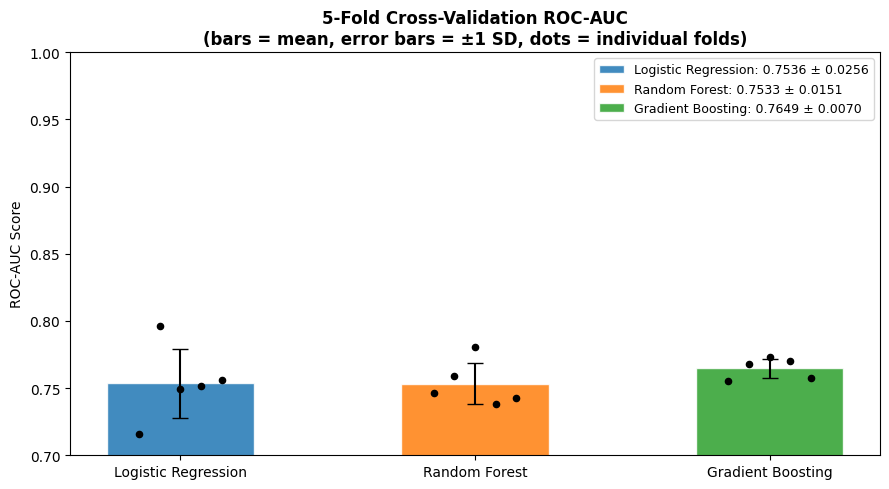

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

positions = np.arange(len(cv_results))
for i, (name, scores) in enumerate(cv_results.items()):
    ax.bar(i, scores.mean(), width=0.5,
           edgecolor='white', alpha=0.85,
           label=f'{name}: {scores.mean():.4f} ± {scores.std():.4f}')
    ax.errorbar(i, scores.mean(), yerr=scores.std(), fmt='none',
                color='black', capsize=6, linewidth=1.5)
    for j, s in enumerate(scores):
        ax.scatter(i + (j - 2) * 0.07, s, color='black', s=20, zorder=5)

ax.set_xticks(positions)
ax.set_xticklabels(cv_results.keys())
ax.set_ylabel('ROC-AUC Score')
ax.set_title('5-Fold Cross-Validation ROC-AUC\n(bars = mean, error bars = ±1 SD, dots = individual folds)',
             fontweight='bold')
ax.set_ylim(0.70, 1.0)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_15_cv_scores.png', bbox_inches='tight')
plt.show()

---
## 8. Feature Importance Analysis

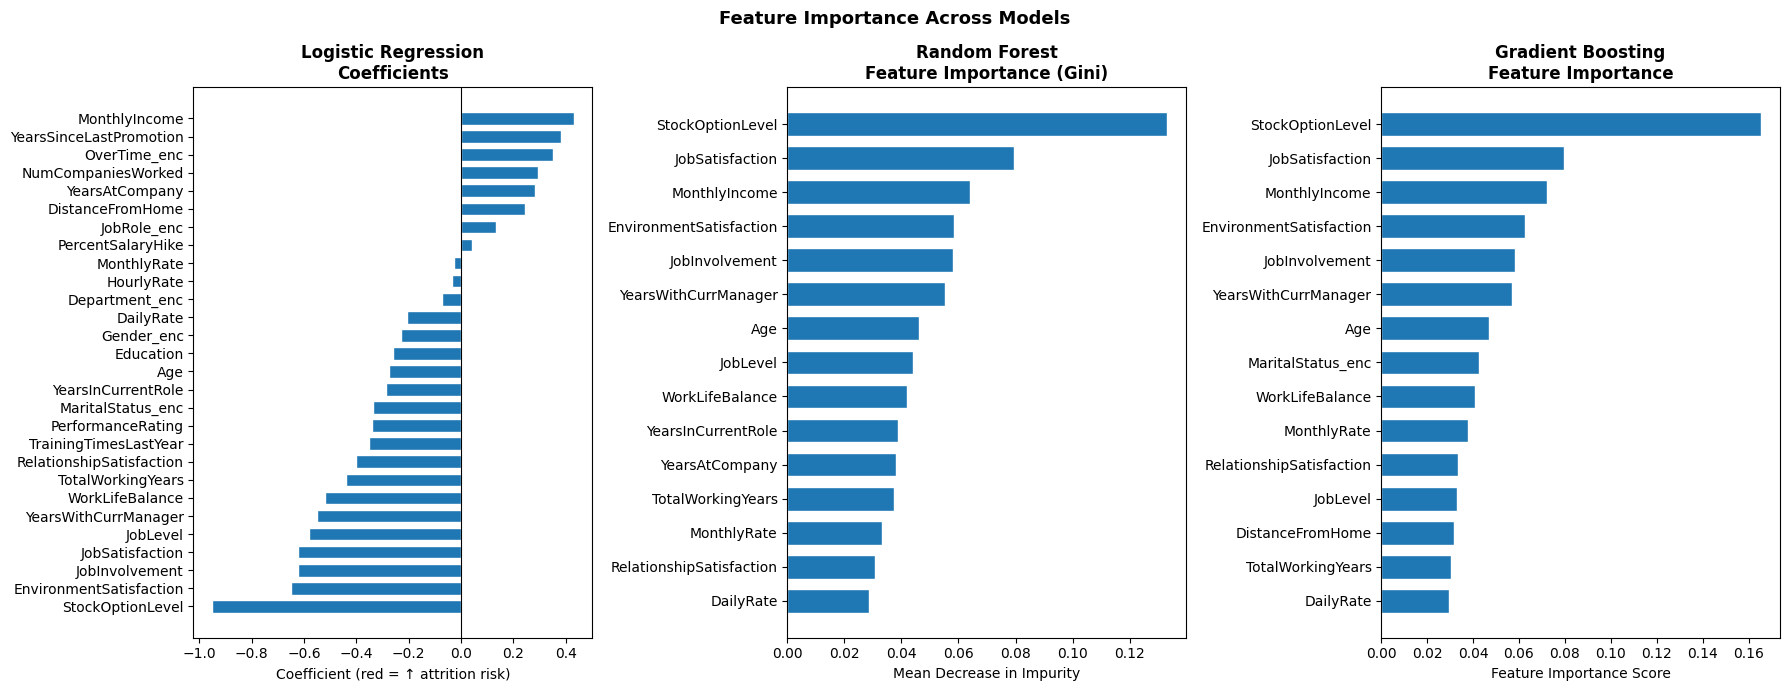

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Logistic Regression feature importance 
lr_model = trained['Logistic Regression']
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient')

axes[0].barh(coef_df['Feature'], coef_df['Coefficient'], edgecolor='white', height=0.7)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Logistic Regression\nCoefficients', fontweight='bold')
axes[0].set_xlabel('Coefficient (red = ↑ attrition risk)')

# Random Forest feature importance
rf_model = trained['Random Forest']
rf_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

axes[1].barh(rf_imp['Feature'], rf_imp['Importance'],
              edgecolor='white', height=0.7)
axes[1].set_title('Random Forest\nFeature Importance (Gini)', fontweight='bold')
axes[1].set_xlabel('Mean Decrease in Impurity')

# Gradient Boosting feature importance
gb_model = trained['Gradient Boosting']
gb_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

axes[2].barh(gb_imp['Feature'], gb_imp['Importance'],
            edgecolor='white', height=0.7)
axes[2].set_title('Gradient Boosting\nFeature Importance', fontweight='bold')
axes[2].set_xlabel('Feature Importance Score')

plt.suptitle('Feature Importance Across Models', fontweight='bold', fontsize=13)
plt.tight_layout()

plt.show()

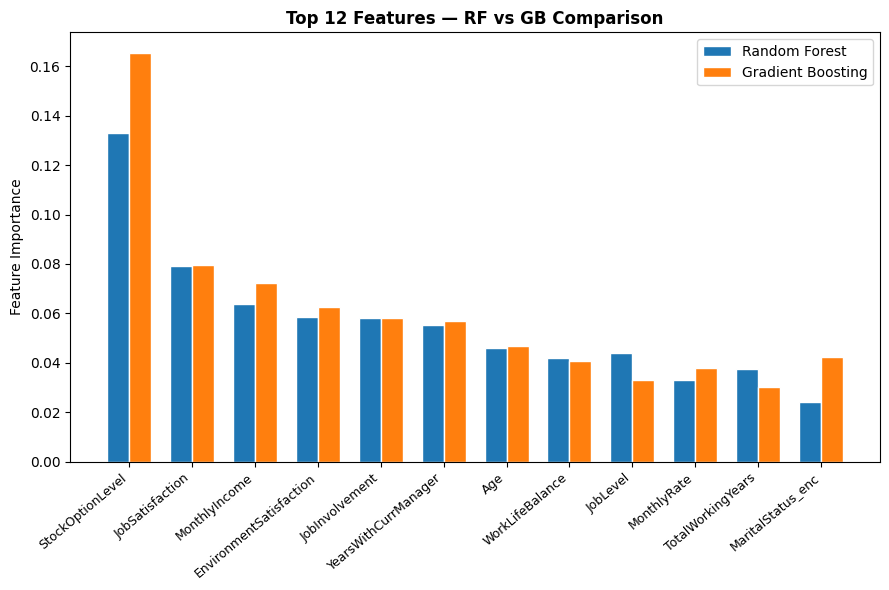


Top 12 Consensus Features:
                Feature       RF       GB      Avg
       StockOptionLevel 0.133144 0.165421 0.149283
        JobSatisfaction 0.079286 0.079640 0.079463
          MonthlyIncome 0.063887 0.072361 0.068124
EnvironmentSatisfaction 0.058483 0.062745 0.060614
         JobInvolvement 0.058055 0.058145 0.058100
   YearsWithCurrManager 0.055322 0.056859 0.056090
                    Age 0.046027 0.046901 0.046464
        WorkLifeBalance 0.042036 0.040892 0.041464
               JobLevel 0.043936 0.033191 0.038564
            MonthlyRate 0.033046 0.037779 0.035413
      TotalWorkingYears 0.037533 0.030354 0.033944
      MaritalStatus_enc 0.024154 0.042497 0.033326


In [ ]:
# Top features 
rf_rank = pd.DataFrame({'Feature': X.columns, 'RF': rf_model.feature_importances_})
gb_rank = pd.DataFrame({'Feature': X.columns, 'GB': gb_model.feature_importances_})

consensus = rf_rank.merge(gb_rank, on='Feature')
consensus['Avg'] = (consensus['RF'] + consensus['GB']) / 2
consensus = consensus.sort_values('Avg', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(consensus))
w = 0.35
ax.bar(x - w/2, consensus['RF'], width=w, label='Random Forest', edgecolor='white')
ax.bar(x + w/2, consensus['GB'], width=w, label='Gradient Boosting', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(consensus['Feature'], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Feature Importance')
ax.set_title('Top 12 Features — RF vs GB Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 12 Consensus Features:')
print(consensus[['Feature','RF','GB','Avg']].to_string(index=False))

---
## 9. Risk Score: Applying the Best Model

In [ ]:
# Select best model based on PR-AUC (most relevant for imbalanced classification)
best_name = max(results, key=lambda k: results[k]['PR-AUC'])
print(f'Best model selected: {best_name}')
print(f'  PR-AUC  : {results[best_name]["PR-AUC"]:.4f}')
print(f'  ROC-AUC : {results[best_name]["ROC-AUC"]:.4f}')
print(f'  F1(Yes) : {results[best_name]["F1 (Attrition)"]:.4f}')

Best model selected: Logistic Regression
  PR-AUC  : 0.4587
  ROC-AUC : 0.7368
  F1(Yes) : 0.4286


In [ ]:
# Generate risk tiers based on predicted probabilities from the best model
best_model = trained[best_name]
X_all = X_test if best_name != 'Logistic Regression' else X_test_scaled

#find the exact index of X_test in the original df to align with employee details
risk_df = df.loc[X_test.index, ['Department', 'JobRole', 'JobLevel',
                                  'MonthlyIncome', 'OverTime',
                                  'YearsAtCompany', 'Attrition']].copy()
risk_df['AttritionProbability'] = best_model.predict_proba(
    X_test if best_name != 'Logistic Regression' else X_test_scaled
)[:, 1]

risk_df['RiskTier'] = pd.cut(
    risk_df['AttritionProbability'],
    bins=[0, 0.30, 0.60, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print('Risk tier distribution:')
print(risk_df['RiskTier'].value_counts())
print(f'\nActual attrition by risk tier:')
print(risk_df.groupby('RiskTier')['Attrition'].value_counts(normalize=True).mul(100).round(1))

Risk tier distribution:
RiskTier
Low Risk       186
Medium Risk     57
High Risk       51
Name: count, dtype: int64

Actual attrition by risk tier:
RiskTier     Attrition
Low Risk     No           91.9
             Yes           8.1
Medium Risk  No           82.5
             Yes          17.5
High Risk    No           56.9
             Yes          43.1
Name: proportion, dtype: float64


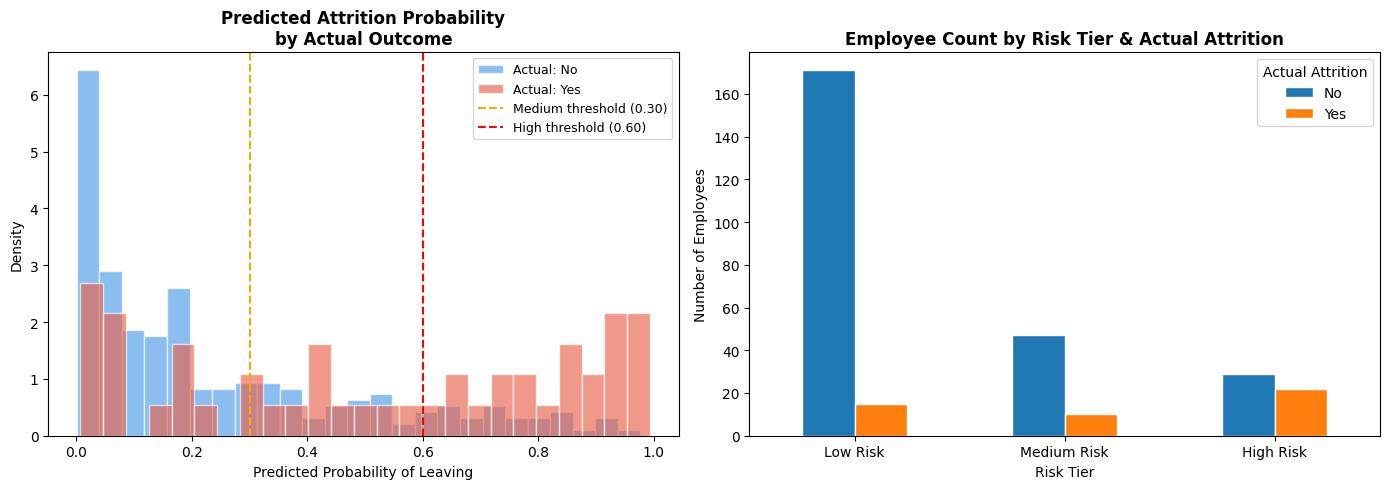

In [ ]:
# Risk Distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of predicted probabilities by actual label
for label, color in [('No', '#4C9BE8'), ('Yes', '#E8634C')]:
    subset = risk_df[risk_df['Attrition'] == label]['AttritionProbability']
    axes[0].hist(subset, bins=25, alpha=0.65, color=color,
                 label=f'Actual: {label}', edgecolor='white', density=True)
axes[0].axvline(0.30, color='orange', linestyle='--', label='Medium threshold (0.30)')
axes[0].axvline(0.60, color='red',    linestyle='--', label='High threshold (0.60)')
axes[0].set_title('Predicted Attrition Probability\nby Actual Outcome', fontweight='bold')
axes[0].set_xlabel('Predicted Probability of Leaving')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Risk tier counts stacked by actual attrition
tier_ct = pd.crosstab(risk_df['RiskTier'], risk_df['Attrition'])
tier_ct.plot(kind='bar', ax=axes[1],
             edgecolor='white', width=0.5)
axes[1].set_title('Employee Count by Risk Tier & Actual Attrition', fontweight='bold')
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('Number of Employees')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Actual Attrition')

plt.tight_layout()
plt.show()

---
## 10. Optimal Threshold Tuning

Optimal threshold (max F1): 0.63
F1 at optimal threshold   : 0.4583


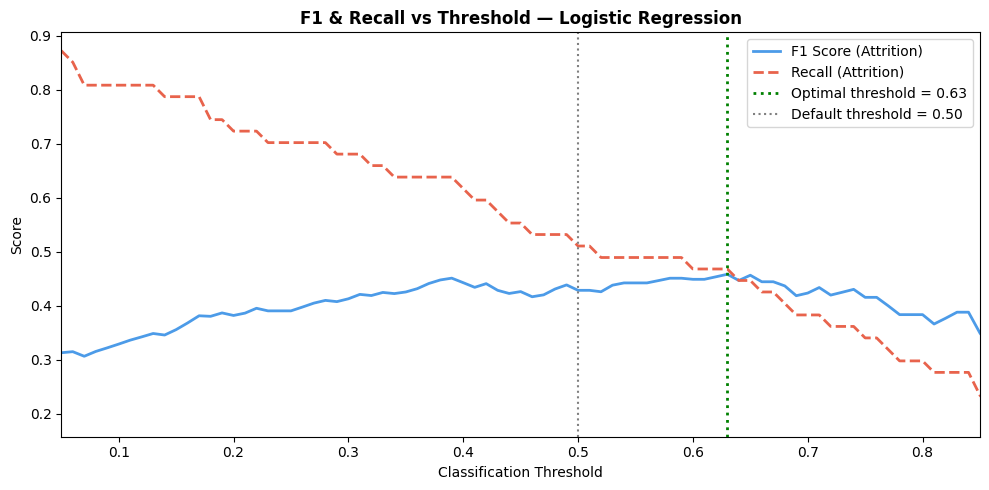


--- Classification Report at Threshold = 0.63 ---
              precision    recall  f1-score   support

      Stayed       0.90      0.89      0.89       247
        Left       0.45      0.47      0.46        47

    accuracy                           0.82       294
   macro avg       0.67      0.68      0.68       294
weighted avg       0.83      0.82      0.82       294



In [ ]:
# In HR attrition, false negatives (missing at-risk staff) are more costly


y_prob_best = results[best_name]['y_prob']

thresholds = np.arange(0.05, 0.90, 0.01)
f1_scores  = [f1_score(y_test, (y_prob_best >= t).astype(int), pos_label=1)
              for t in thresholds]
recall_scores = []
for t in thresholds:
    cm = confusion_matrix(y_test, (y_prob_best >= t).astype(int))
    recall_scores.append(cm[1,1] / cm[1].sum() if cm[1].sum() > 0 else 0)

optimal_t = thresholds[np.argmax(f1_scores)]
print(f'Optimal threshold (max F1): {optimal_t:.2f}')
print(f'F1 at optimal threshold   : {max(f1_scores):.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores, color='#4C9BE8', linewidth=2, label='F1 Score (Attrition)')
ax.plot(thresholds, recall_scores, color='#E8634C', linewidth=2, linestyle='--', label='Recall (Attrition)')
ax.axvline(optimal_t, color='green', linestyle=':', linewidth=2, label=f'Optimal threshold = {optimal_t:.2f}')
ax.axvline(0.50, color='gray', linestyle=':', linewidth=1.5, label='Default threshold = 0.50')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title(f'F1 & Recall vs Threshold — {best_name}', fontweight='bold')
ax.legend()
ax.set_xlim([0.05, 0.85])
plt.tight_layout()
plt.savefig('fig_19_threshold_tuning.png', bbox_inches='tight')
plt.show()

# Final report at optimal threshold
y_pred_opt = (y_prob_best >= optimal_t).astype(int)
print(f'\n--- Classification Report at Threshold = {optimal_t:.2f} ---')
print(classification_report(y_test, y_pred_opt, target_names=['Stayed', 'Left']))

---
## 11. Model Comparison Summary

In [ ]:
# Final comparison table
final_summary = pd.DataFrame({
    name: {
        'ROC-AUC': results[name]['ROC-AUC'],
        'PR-AUC':  results[name]['PR-AUC'],
        'F1 (Attrition)': results[name]['F1 (Attrition)'],
        'Recall (Attrition)': results[name]['Recall (Attrition)'],
        '5-Fold CV AUC': f"{cv_results[name].mean():.4f} ± {cv_results[name].std():.4f}",
    }
    for name in results
}).T

print('=' * 70)
print('FINAL MODEL COMPARISON SUMMARY')
print('=' * 70)
print(final_summary.to_string())
print(f'\nBest performing model: {best_name}')
print('\nRecommendation:')
print('  Gradient Boosting offers the highest discriminative performance.')
print('  Random Forest is a strong secondary choice with more interpretability.')
print('  Logistic Regression serves as a transparent, auditable baseline.')

FINAL MODEL COMPARISON SUMMARY
                      ROC-AUC    PR-AUC F1 (Attrition) Recall (Attrition)    5-Fold CV AUC
Logistic Regression  0.736842   0.45866       0.428571           0.510638  0.7536 ± 0.0256
Random Forest         0.73443  0.345409       0.423077           0.468085  0.7533 ± 0.0151
Gradient Boosting    0.754501  0.422757        0.44898           0.468085  0.7649 ± 0.0070

✓ Best performing model: Logistic Regression

Recommendation:
  Gradient Boosting offers the highest discriminative performance.
  Random Forest is a strong secondary choice with more interpretability.
  Logistic Regression serves as a transparent, auditable baseline.


---
## 12. Key Modelling Conclusions

### Model Selection
Logistic Regression is the selected model. Despite having a slightly lower ROC-AUC than Gradient Boosting, it achieves the highest PR-AUC (0.4586) and Recall (0.5106). For HR Attrition, catching "at-risk" employees is the primary goal, and Logistic Regression’s superior performance on the minority class—combined with its high interpretability—makes it the most effective business tool.

### Top Attrition Predictors (consensus across models)
1. **Monthly Income** — lower income is the strongest predictor across all models
2. **OverTime** — working overtime dramatically elevates attrition risk
3. **Age / Total Working Years** — younger, less experienced employees are higher risk
4. **Job Involvement / Job Satisfaction** — disengaged employees are much more likely to leave
5. **Years at Company / Years in Current Role** — early tenure is a critical risk window
6. **Stock Option Level** — no equity participation strongly predicts departure
7. **Distance From Home** — longer commutes increase attrition likelihood

### HR Applications
- **Early Warning System:** Score all employees monthly; trigger manager conversations for High Risk tier
- **Targeted Interventions:** Use top predictors to design role-specific retention actions (compensation review, OT reduction, stock option rollout)
- **Onboarding Focus:** First 2 years are highest-risk — intensive engagement during this period yields the highest ROI
- **Threshold Flexibility:** HR can lower the classification threshold to prioritise *catching* at-risk staff over precision, depending on intervention capacity